# Stage 2 — Person Tracking Evaluation

Run ByteTrack multi-person tracking on top of detection results from Stage 1.

**What this notebook covers:**
- Loading detections from `PipelineCache` (or re-running detection inline)
- Running `pipeline.track.PersonTracker` (ByteTrack) per frame
- Visualising track IDs, confirmed vs tentative tracks
- Track continuity analysis (id switches, ghost tracks)
- Saving tracks to cache for Stage 3 (pose)

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = Path('../data/raw_footage/agility_test.mp4')
TARGET_FPS = 15
MAX_FRAMES = 60
JOB_ID     = 'notebook-eval-detection'   # match job_id from 01_detection_eval

from pipeline.cache import PipelineCache
cache = PipelineCache(job_id=JOB_ID, cache_root=Path('../data/cache'))
print("Stages cached:", cache.summary().get('stages_cached', []))

Stages cached: ['ingest', 'detect', 'track']


In [2]:
# ── Load frames ──────────────────────────────────────────────────────────────
from pipeline.ingest import extract_frames

frames, frame_indices, timestamps = [], [], []
for fi, frame, ts in extract_frames(str(VIDEO_PATH), target_fps=TARGET_FPS):
    frames.append(frame)
    frame_indices.append(fi)
    timestamps.append(ts)
    if MAX_FRAMES and len(frames) >= MAX_FRAMES:
        break

# ── Load or recompute detections ──────────────────────────────────────────────
if cache.has('detect'):
    print("Loading detections from cache...")
    all_detections = cache.load_detections()[:len(frames)]
else:
    from pipeline.detect import PersonDetector
    detector = PersonDetector()
    all_detections = []
    for i, frame in enumerate(frames):
        dets = detector.detect(frame)
        for d in dets: d.frame_idx = frame_indices[i]
        all_detections.append(dets)
    cache.save_detections(all_detections)
    print(f"Detection complete. {sum(len(d) for d in all_detections)} total detections.")

Loading detections from cache...


In [3]:
# ── Run tracking ─────────────────────────────────────────────────────────────
from pipeline.track import PersonTracker

tracker = PersonTracker()
all_tracks = []

for i, (frame, dets) in enumerate(zip(frames, all_detections)):
    tracks = tracker.update(dets, frame_idx=frame_indices[i])
    all_tracks.append(tracks)
    if i % 10 == 0:
        confirmed = [t for t in tracks if t.is_confirmed]
        print(f"  frame {frame_indices[i]:4d}  t={timestamps[i]:.2f}s  "
              f"tracks={len(tracks)} (confirmed={len(confirmed)})")

cache.save_tracks(all_tracks)
print(f"\nTracking complete. Saved to cache.")

  frame    0  t=0.00s  tracks=5 (confirmed=5)
  frame   40  t=0.67s  tracks=5 (confirmed=5)
  frame   80  t=1.33s  tracks=5 (confirmed=5)
  frame  120  t=2.00s  tracks=5 (confirmed=5)
  frame  160  t=2.67s  tracks=5 (confirmed=5)
  frame  200  t=3.33s  tracks=5 (confirmed=5)

Tracking complete. Saved to cache.


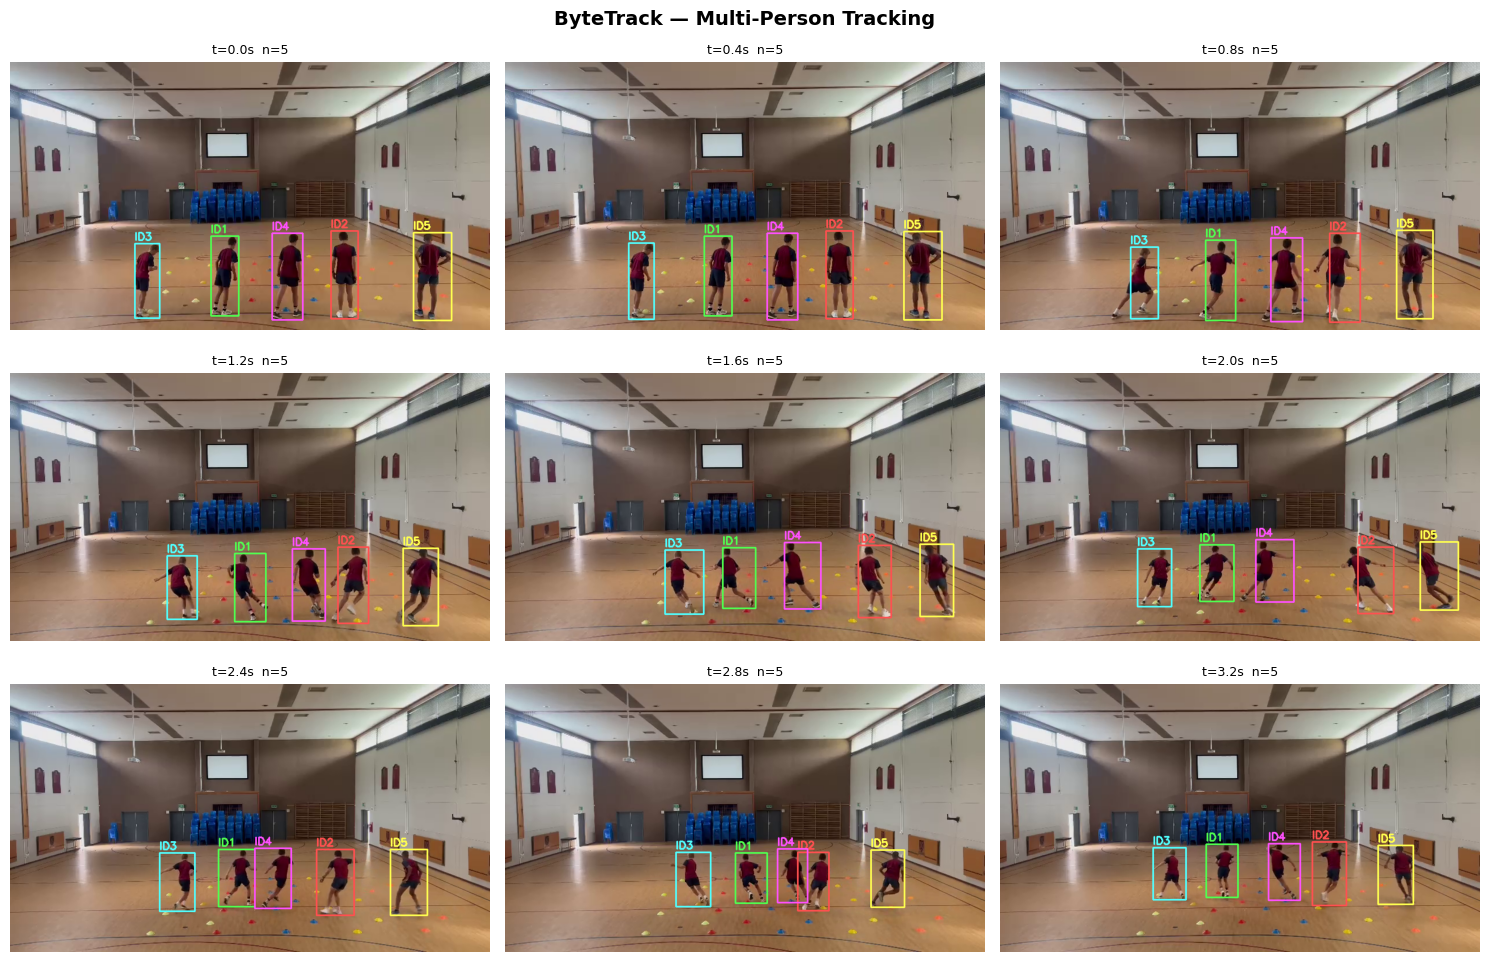

In [4]:
# ── Assign colours per track_id ───────────────────────────────────────────────
PALETTE = [
    (255, 80, 80), (80, 255, 80), (80, 80, 255),
    (255, 255, 80), (255, 80, 255), (80, 255, 255),
    (255, 160, 80), (160, 80, 255), (80, 160, 255),
]

def track_colour(track_id):
    return PALETTE[track_id % len(PALETTE)]

# ── Visualise tracking on a 3×3 frame grid ───────────────────────────────────
SAMPLE_EVERY = max(1, len(frames) // 9)
sample_idx   = list(range(0, len(frames), SAMPLE_EVERY))[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, fi in zip(axes.flat, sample_idx):
    canvas = frames[fi].copy()
    for track in all_tracks[fi]:
        x1, y1, x2, y2 = [int(v) for v in track.bbox]
        col = track_colour(track.track_id)
        thickness = 2 if track.is_confirmed else 1
        cv2.rectangle(canvas, (x1, y1), (x2, y2), col, thickness)
        label = f"ID{track.track_id}"
        if not track.is_confirmed:
            label += "?"
        cv2.putText(canvas, label, (x1, max(y1-6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f"t={timestamps[fi]:.1f}s  n={len(all_tracks[fi])}", fontsize=9)
    ax.axis('off')

plt.suptitle('ByteTrack — Multi-Person Tracking', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Unique track IDs seen: [1, 2, 3, 4, 5]

Track lifetimes (frames):
  ID  1  frames= 60  duration=4.0s  first=0.0s  last=3.9s
  ID  2  frames= 60  duration=4.0s  first=0.0s  last=3.9s
  ID  3  frames= 60  duration=4.0s  first=0.0s  last=3.9s
  ID  4  frames= 60  duration=4.0s  first=0.0s  last=3.9s
  ID  5  frames= 60  duration=4.0s  first=0.0s  last=3.9s


ValueError: (80, 255, 80) is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

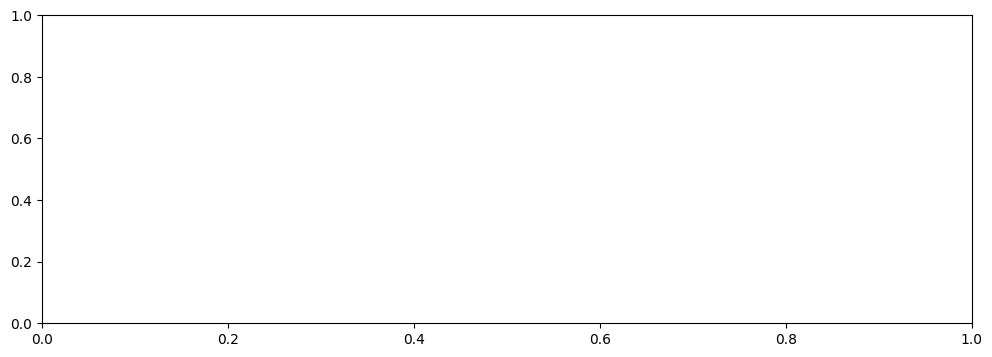

In [6]:
# ── Track continuity analysis ─────────────────────────────────────────────────
from collections import defaultdict

track_lifetimes = defaultdict(list)
for fi, frame_tracks in enumerate(all_tracks):
    for t in frame_tracks:
        track_lifetimes[t.track_id].append(fi)

print(f"Unique track IDs seen: {sorted(track_lifetimes.keys())}")
print(f"\nTrack lifetimes (frames):")
for tid, frames_seen in sorted(track_lifetimes.items()):
    duration_s = len(frames_seen) / TARGET_FPS
    print(f"  ID {tid:2d}  frames={len(frames_seen):3d}  duration={duration_s:.1f}s  "
          f"first={timestamps[frames_seen[0]]:.1f}s  last={timestamps[frames_seen[-1]]:.1f}s")

fig, ax = plt.subplots(figsize=(12, 4))
for tid, frames_seen in sorted(track_lifetimes.items()):
    xs = [timestamps[f] for f in frames_seen]
    ax.plot(xs, [tid] * len(xs), lw=4, color=track_colour(tid), solid_capstyle='round')

ax.set_xlabel('Time (s)'); ax.set_ylabel('Track ID')
ax.set_title('Track Lifetimes'); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()